## Linear Regression Analysis

In this project, I aim to:

1.   Gain practical experience working with a linear regression model.
2.   Explore and apply the Mean Absolute Error (MAE) metric to evaluate model performance.
3.   Learn how to handle and incorporate categorical features in a linear regression task.




In this project, I work with a dataset that contains information about medical insurance costs charged to clients by insurance companies.

The goal is to use this data to build a model that predicts insurance expenses based on individual client characteristics.

**Dataset Description:**

*age*: age of the client;

*sex*: gender (female/male);

*bmi*: body mass index ;

*children*: number of dependents covered by the insurance;

*smoker*: whether the client is a smoker or not;

*region*: residential area in the U.S. (northeast, southeast, southwest, northwest);

*charges*: medical insurance costs.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split 

In [3]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**Data Preparation**

As an initial step, I perform basic data filtering and exploratory analysis on the dataset:

1. I create a new DataFrame that includes only female clients with no children and insurance charges below $15,000.
2. I then visualize the relationship between age and insurance charges to better understand how costs vary across this group.

(228, 7)


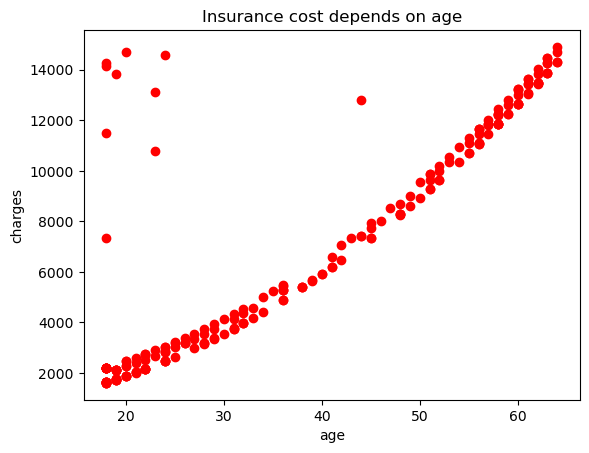

In [4]:
# Ваш код здесь
df_new = df[(df.children==0) & (df.charges<15000) & (df.sex=='female')]
print(df_new.shape)
plt.plot(df_new['age'], df_new['charges'], 'ro')
plt.xlabel('age')
plt.ylabel('charges')
plt.title('Insurance cost depends on age')
plt.show()

**Outlier Removal and Linear Regression Modeling**

In this stage, I focus on cleaning the data and building a baseline linear regression model:

3. I remove outliers from the charges variable (specifically the extreme values identified during exploratory analysis) and recreate the plot to confirm that they have been successfully eliminated.
4. I split the dataset into training and testing sets using an 80/20 ratio.
5. I train a linear regression model with default parameters using a single feature — age — and evaluate its performance on the test set using the Mean Absolute Error (MAE) metric.

(218, 7)


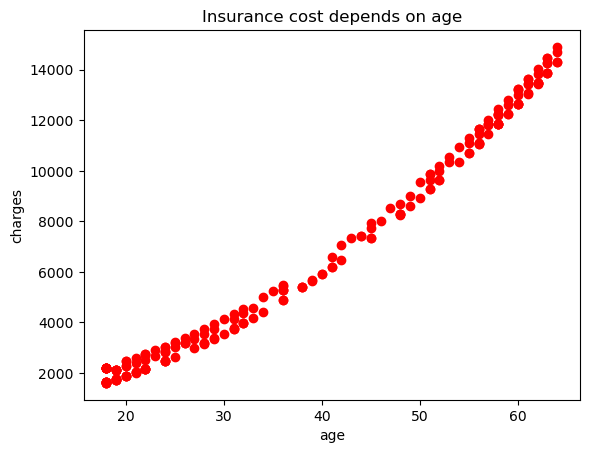

In [5]:
# Ваш код здесь
indx = df_new[(df_new.charges > 6000) & (df_new.age < 30)].index
indx2 = df_new[(df_new.charges > 12000) & (df_new.age < 50)].index
df_new = df_new.drop(list(indx) + list(indx2))
print(df_new.shape)
plt.plot(df_new['age'], df_new['charges'], 'ro')
plt.xlabel('age')
plt.ylabel('charges')
plt.title('Insurance cost depends on age')
plt.show()

In [6]:
train, test = train_test_split(df_new, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(train[['age']], train.charges)
pred = lr.predict(test[['age']])
mean_absolute_error(test.charges, pred)

589.2828328455392

**Linear Regression with Multiple Features**

In this step, I extend the baseline model by incorporating multiple features:

1. I train a linear regression model with default parameters using all available continuous features from the dataset. Before training, I remove any features that contain only a single constant value, as they do not contribute to the model.
2. I evaluate the updated model on the test set using the Mean Absolute Error (MAE) metric.
3. I then compare the new MAE score with the result from the previous step to determine whether the model performance has improved.

This allows me to assess how adding more relevant features impacts the predictive power of the model.

In [7]:
# Ваш код здесь
new_cols = ['age', 'bmi', 'charges']
train, test = train_test_split(df_new[new_cols], test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(train.drop(['charges'], axis=1), train.charges)
pred = lr.predict(test.drop(['charges'], axis=1))
mean_absolute_error(test.charges, pred)

590.8305083474559

**Linear Regression with Categorical Features**

In this final step, I build a more complete model by using all available features in the dataset, including categorical variables:

1. I train a linear regression model with default parameters using the full set of features. Before training, I remove any features that contain only a single unique value, as they do not provide useful information.
2. I encode categorical variables using OneHotEncoder to make them suitable for the regression model.
3. I evaluate the model on the test set using the Mean Absolute Error (MAE) metric.
4. Finally, I compare the results with previous models to determine whether including categorical features improves performance.

This step highlights the importance of proper feature encoding in improving linear regression performance.

In [8]:
# Ваш код здесь
df_new.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,218.000000,218,218.000000,218.0,218,218,218.000000
unique,NaN,1,NaN,NaN,1,4,NaN
top,NaN,female,NaN,NaN,no,northeast,NaN
freq,NaN,218,NaN,NaN,218,58,NaN
mean,38.775229,NaN,30.310986,0.0,NaN,NaN,6739.594019
std,16.416243,NaN,5.958165,0.0,NaN,NaN,4455.839013
min,18.000000,NaN,17.290000,0.0,NaN,NaN,1607.510100
25%,22.000000,NaN,26.053750,0.0,NaN,NaN,2475.245350
50%,36.000000,NaN,29.925000,0.0,NaN,NaN,5269.996975
75%,56.000000,NaN,34.727500,0.0,NaN,NaN,11412.150800


In [9]:
df_new2 = df_new.drop(['sex', 'children', 'smoker'], axis=1)

train, test = train_test_split(df_new2, test_size=0.2, random_state=42)
train.head()

,age,bmi,region,charges
521,32,44.220,southeast,3994.17780
579,25,23.465,northeast,3206.49135
671,29,31.160,northeast,3943.59540
789,62,29.920,southeast,13457.96080
523,38,37.730,southeast,5397.61670


In [10]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore')
train_enc = pd.DataFrame(ohe.fit_transform(train[['region']]).toarray(), columns = ohe.get_feature_names_out(['region']))
test_enc = pd.DataFrame(ohe.transform(test[['region']]).toarray(), columns = ohe.get_feature_names_out(['region']))

train_enc.head()

,region_northeast,region_northwest,region_southeast,region_southwest
0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


In [11]:
train = train.join(train_enc.set_index(train.index)).drop(['region'], axis=1)
test = test.join(test_enc.set_index(test.index)).drop(['region'], axis=1)
train.head()

,age,bmi,charges,region_northeast,region_northwest,region_southeast,region_southwest
521,32,44.220,3994.17780,0.0,0.0,1.0,0.0
579,25,23.465,3206.49135,1.0,0.0,0.0,0.0
671,29,31.160,3943.59540,1.0,0.0,0.0,0.0
789,62,29.920,13457.96080,0.0,0.0,1.0,0.0
523,38,37.730,5397.61670,0.0,0.0,1.0,0.0


In [12]:
lr.fit(train.drop(['charges'], axis=1), train.charges)
pred = lr.predict(test.drop(['charges'], axis=1))
mean_absolute_error(test.charges, pred)

535.5915097964669

## Model Improvement and Feature Engineering

In this final experiment, I train a linear regression model on the full insurance.csv dataset and focus on improving its performance through better data preprocessing and feature engineering.

To enhance the model’s predictive quality, I apply several strategies:

- I analyze the dataset for outliers and consider how to handle them in a way that prevents them from negatively affecting the model’s performance.
- I select only the most relevant features by evaluating their relationship with the target variable. For this, I use correlation analysis as well as visual inspection of how categorical variables relate to insurance charges.
- I apply feature scaling to normalize the input data, which helps improve model stability and performance.
- I experiment with feature engineering by creating new variables, for example, converting age into categorical groups such as “young” and “older”.

This step focuses on improving model quality through better data preparation rather than changing the model itself.

In [14]:
df2 = pd.read_csv('insurance.csv')
df2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


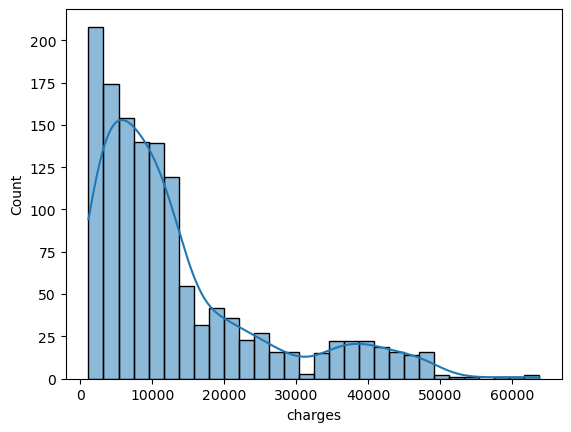

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df2['charges'], kde=True)
plt.show()

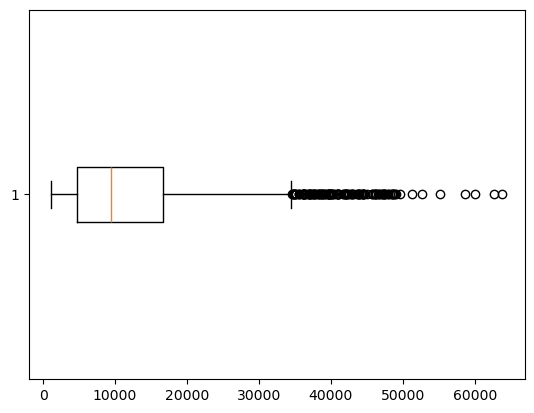

In [17]:
plt.boxplot(df2['charges'], vert=False)
plt.show()

In [19]:
Q1 = df2['charges'].quantile(0.25)
Q3 = df2['charges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-13109.1508975
34489.350562499996


In [20]:
df2 = df2[(df2['charges'] >= lower) & (df2['charges'] <= upper)]

In [21]:
df2.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.119505,0.040215,0.437642
bmi,0.119505,1.000000,0.002736,-0.066495
children,0.040215,0.002736,1.000000,0.083713
charges,0.437642,-0.066495,0.083713,1.000000


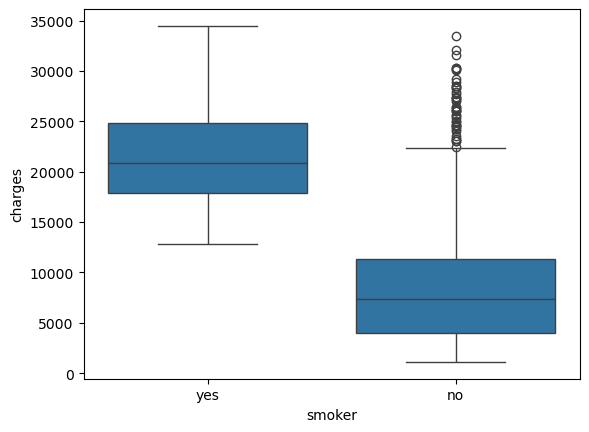

In [22]:
sns.boxplot(x='smoker', y='charges', data=df2)
plt.show()

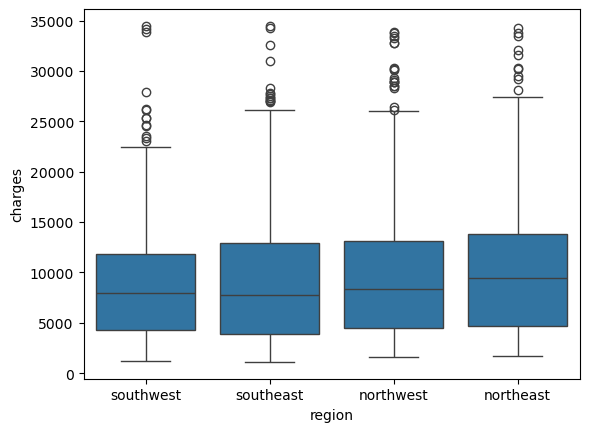

In [23]:
sns.boxplot(x='region', y='charges', data=df2)
plt.show()

In [24]:
df2 = pd.get_dummies(df2, drop_first=True)

In [25]:
print(df2.columns)

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [26]:
df2['age_group'] = pd.cut(
    df['age'],
    bins=[0,30,50,100],
    labels=[0,1,2]
)

In [27]:
df2['bmi_smoker'] = df2['bmi'] * df2['smoker_yes']

In [28]:
x = df2.drop(df2[['charges']], axis=1)
y = df2['charges']

In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [31]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [32]:
from sklearn.metrics import r2_score
y_pred = model.predict(x_test)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.564045694315708
MAE: 2593.913822566397
